In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from numpycnn import (
    Conv2D, Pooling2D, Flatten, Dense, LayerNorm, Dropout,
    Adam, LRScheduler, ImageDataAugmentor,
    categorical_crossentropy, load_fashion_mnist,
)
from numpycnn.model import Model

## Load Dataset
Choose one: Fashion-MNIST (grayscale 28x28) or CIFAR-10 (color 32x32).

In [2]:
(X_train, y_train), (X_test, y_test) = load_fashion_mnist()
y_train = np.eye(10)[y_train]
y_test = np.eye(10)[y_test]

train_size = int(0.9 * X_train.shape[0])
X_val, y_val = X_train[train_size:], y_train[train_size:]
X_train, y_train = X_train[:train_size], y_train[:train_size]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (54000, 28, 28, 1), Val: (6000, 28, 28, 1), Test: (10000, 28, 28, 1)


## Data Augmentation

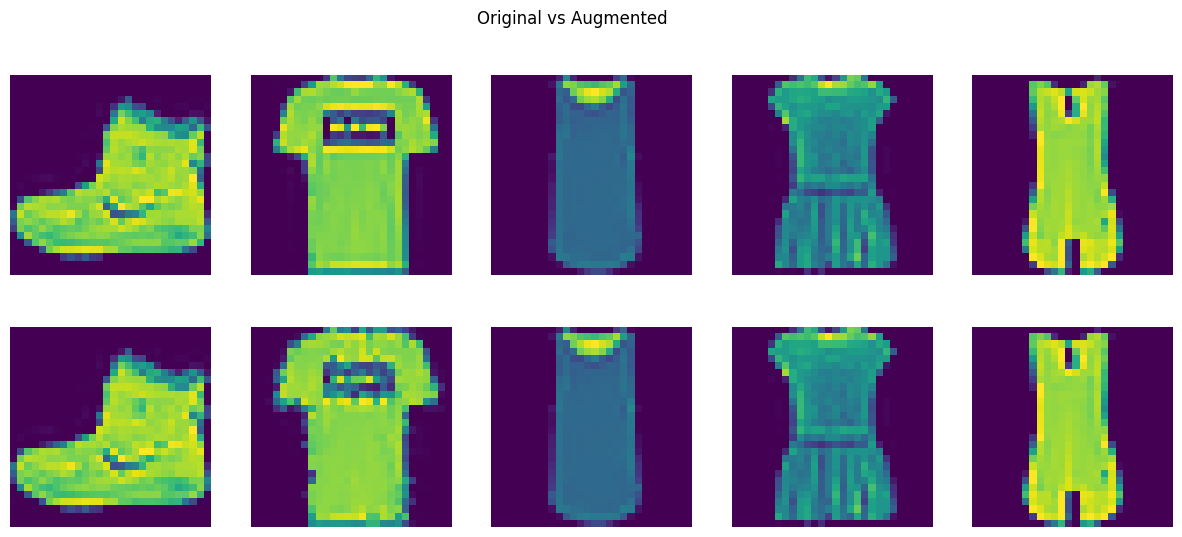

In [3]:
augmentations = [
    (lambda self, img: self.add_gaussian_noise(img, std=np.random.uniform(0.01, 0.2)), 0.15),
    (lambda self, img: self.add_salt_pepper_noise(img, salt_prob=np.random.uniform(0.01, 0.1), pepper_prob=np.random.uniform(0.01, 0.1)), 0.1),
    (lambda self, img: self.jitter(img, sigma=np.random.uniform(0.1, 0.5)), 0.15),
]
augmentor = ImageDataAugmentor(augmentations=augmentations)

sample = X_train[:5]
augmented = augmentor.augment(sample, target_shape=(28, 28))
is_gray = sample.shape[-1] == 1

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Original vs Augmented")
for i in range(5):
    axes[0, i].imshow(np.squeeze(sample[i]), cmap='viridis' if is_gray else None)
    axes[0, i].axis('off')
    axes[1, i].imshow(np.squeeze(augmented[i]), cmap='viridis' if is_gray else None)
    axes[1, i].axis('off')
plt.show()

## Build Model

In [4]:
model = Model()

model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same'))
model.add(LayerNorm())
model.add(Pooling2D(pool_size=(2, 2), stride=2, mode='max'))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(LayerNorm())
model.add(Pooling2D(pool_size=(2, 2), stride=2, mode='max'))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(LayerNorm())
model.add(Dense(64, activation='relu'))
model.add(LayerNorm())
model.add(Dense(10, activation='softmax'))

optimizer = Adam(use_agc=True)
model.compile(input_shape=(None, 28, 28, 1), optimizer=optimizer, initializer='he')
model.summary()

Layer #   OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)   ACTIVATION
0        Convolution2D               28x28x32          832        0.2% RELU
1        LayerNorm                   28x28x32           64        0.0% 
2        Pooling2D                   14x14x32            0        0.0% MAX
3        Convolution2D               14x14x64        18496        4.3% RELU
4        LayerNorm                   14x14x64          128        0.0% 
5        Pooling2D                     7x7x64            0        0.0% MAX
6        Flatten                         3136            0        0.0% 
7        Dense                            128       401536       93.3% RELU
8        Dropout                          128            0        0.0% 
9        LayerNorm                        128          256        0.1% 
10       Dense                             64         8256        1.9% RELU
11       LayerNorm                         64          128        0.0% 
12       Dense               

## Train

In [5]:
lr_scheduler = LRScheduler(
    initial_lr=0.001,
    lr_decay_factor=0.05,
    step_size=2,
    min_lr=1e-6,
    patience=3,
    cooldown=2,
    patient=True,
)

history = model.fit(
    X_train, y_train, X_val, y_val,
    batch_size=128, epochs=5,
    loss_fn=categorical_crossentropy,
    l2_lambda=0.01,
    lr_scheduler=lr_scheduler,
    checkpoint_path='best_model.pkl',
    augmentor=augmentor,
)


 Epoch 1/5
[========================================>] Batch 422/422 - Loss: 0.3075 - Train Loss: 0.4927 - Train Acc: 0.8896 - Val Loss: 0.3237 - Val Acc: 0.8760
Model saved to best_model.pkl
Checkpoint saved to best_model.pkl

 Epoch 2/5
[========================================>] Batch 422/422 - Loss: 0.3061 - Train Loss: 0.3449 - Train Acc: 0.9125 - Val Loss: 0.2760 - Val Acc: 0.8992
Model saved to best_model.pkl
Checkpoint saved to best_model.pkl

 Epoch 3/5
[========================================>] Batch 422/422 - Loss: 0.3029 - Train Loss: 0.3145 - Train Acc: 0.9236 - Val Loss: 0.2457 - Val Acc: 0.9097
Model saved to best_model.pkl
Checkpoint saved to best_model.pkl

 Epoch 4/5
[========================================>] Batch 422/422 - Loss: 0.2182 - Train Loss: 0.2975 - Train Acc: 0.9292 - Val Loss: 0.2455 - Val Acc: 0.9090
Model saved to best_model.pkl
Checkpoint saved to best_model.pkl

 Epoch 5/5
[========================================>] Batch 422/422 - Loss: 0.3595 - T

## Results

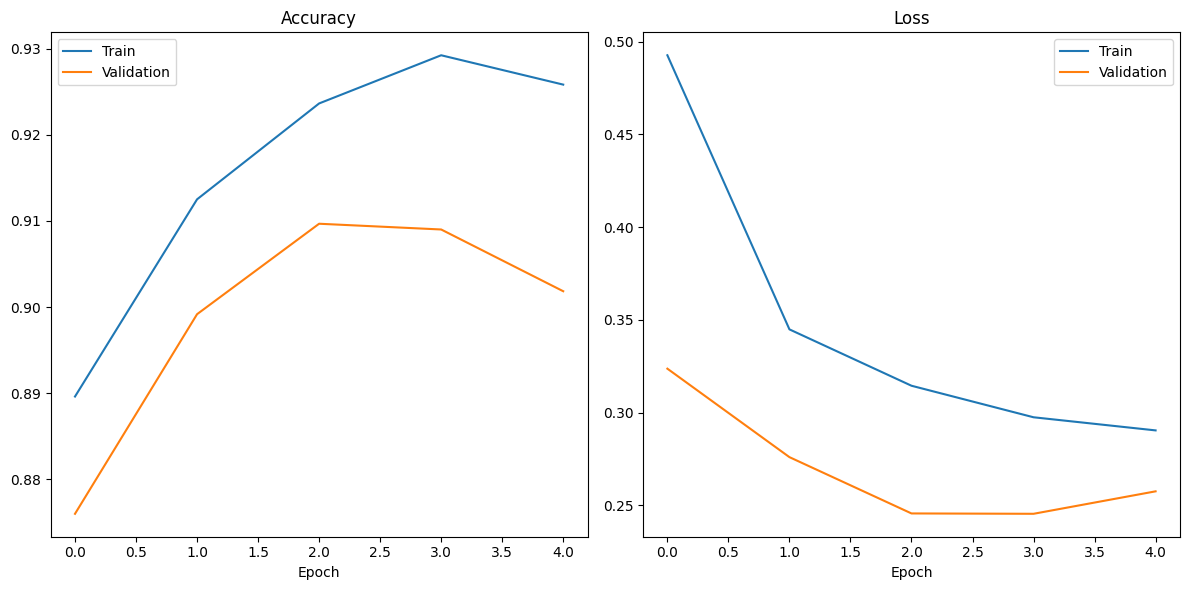

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(history['train_accuracy'], label='Train')
ax1.plot(history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_loss'], label='Train')
ax2.plot(history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [7]:
test_predictions = model.predict(X_test)
test_accuracy = np.mean(np.argmax(test_predictions, axis=1) == np.argmax(y_test, axis=1))
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8974


## Visualize Feature Maps

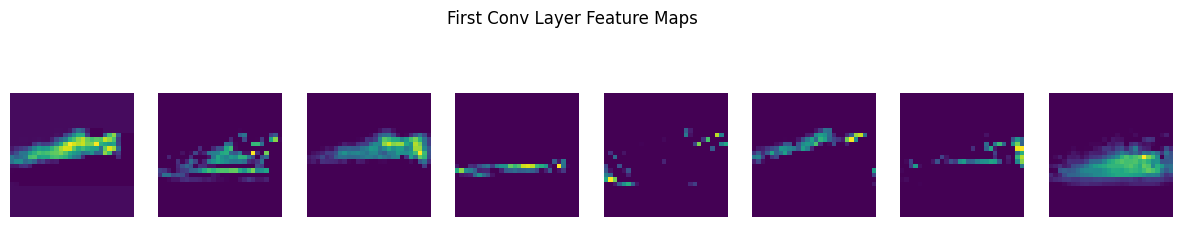

In [8]:
def get_layer_output(model, layer_index, X_sample):
    layer_outputs = []
    current_output = X_sample
    for i, layer in enumerate(model.layers[:layer_index + 1]):
        if layer.layer_type == "SkipConnection":
            skip_input = layer_outputs[layer.skip_from]
            current_output = layer.forward(current_output, skip_input, training=False)
        else:
            current_output = layer.forward(current_output, training=False)
        layer_outputs.append(current_output)
    return current_output

sample = X_val[:9]
layer_output = get_layer_output(model, 0, sample)

fig, axes = plt.subplots(1, min(8, layer_output.shape[-1]), figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(layer_output[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle('First Conv Layer Feature Maps')
plt.show()